In [1]:
import gymnasium as gym
import register_env
env = gym.make("Snake-v0", render_mode='matplotlib')

In [2]:
from stable_baselines3.common.env_checker import check_env

check_env(env)

### Use this to train from scratch

In [ ]:
import gymnasium as gym
import register_env
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor

def kill_tensorboard(port=6006):
    import psutil
    for proc in psutil.process_iter(attrs=['cmdline']):
        if proc.info['cmdline'] and 'tensorboard' in proc.info['cmdline'] and f'--port={port}' in proc.info['cmdline']:
            proc.kill()

kill_tensorboard()
%reload_ext tensorboard

def make_env():
    def _init():
        env = gym.make("Snake-v0", render_mode='ascii')
        env = Monitor(env)
        return env
    return _init

vec_env = DummyVecEnv([make_env()])

model = PPO(
    policy="MlpPolicy",
    env=vec_env,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    tensorboard_log="./snake_logs/",
    verbose=1
)

%tensorboard --logdir snake_logs --reload_interval 2 --port 6006

model.learn(total_timesteps=500_000)
model.save("ppo_snake_1")

Using cpu device


Logging to ./snake_logs/PPO_9
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 19.4     |
|    ep_rew_mean     | -1.1     |
| time/              |          |
|    fps             | 2130     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 19.4        |
|    ep_rew_mean          | -1.06       |
| time/                   |             |
|    fps                  | 1361        |
|    iterations           | 2           |
|    time_elapsed         | 3           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.011440858 |
|    clip_fraction        | 0.11        |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.09       |
|    explained_variance   | -0.119      |


### Use this to re-begin training

In [ ]:
EXISTING_MODEL_PATH = 'models//ppo_snake_continue'
TIME_STEPS = 5_000_000

import os
import sys
import gymnasium as gym
import register_env
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback, BaseCallback
import psutil

sys.path.append('/content/rl-snake')

def kill_tensorboard(port=6006):
    for proc in psutil.process_iter(attrs=['cmdline']):
        cmd = proc.info['cmdline']
        if cmd and 'tensorboard' in cmd and f'--port={port}' in cmd:
            proc.kill()
            print("Killed stale TensorBoard process:", proc.pid)

def make_env():
    def _init():
        env = gym.make("Snake-v0", render_mode='ascii')
        env = Monitor(env)
        return env
    return _init

logdir = "snake_logs"
os.makedirs(logdir, exist_ok=True)

vec_env = DummyVecEnv([make_env()])
model = PPO.load(EXISTING_MODEL_PATH, env=vec_env)

kill_tensorboard(6006)

%load_ext tensorboard
%tensorboard --logdir snake_logs --port 6006 --reload_interval 2

model.learn(total_timesteps=TIME_STEPS)
model.save((EXISTING_MODEL_PATH + "_continue"))

ModuleNotFoundError: No module named 'register_env'

In [ ]:
import os
print(os.getcwd())

/content


In [ ]:
!ls -R .

.:
sample_data

./sample_data:
anscombe.json		      mnist_test.csv
california_housing_test.csv   mnist_train_small.csv
california_housing_train.csv  README.md


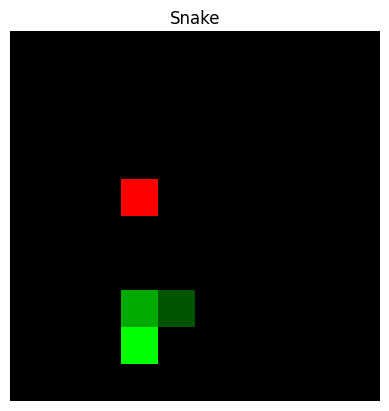

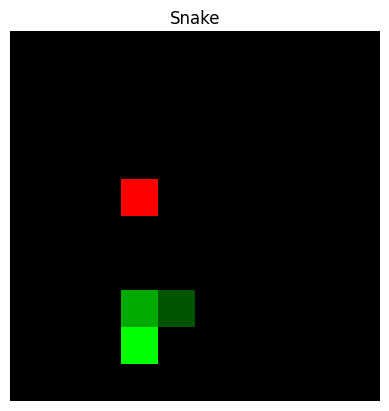

In [ ]:
import gymnasium as gym
import register_env
from stable_baselines3 import PPO
from time import sleep

watch_env = gym.make("Snake-v0", render_mode="matplotlib")
model = PPO.load("ppo_snake_continue")
obs, _ = watch_env.reset()

for _ in range(3000):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = watch_env.step(action)
    
    watch_env.render()

    if terminated or truncated:
        obs, _ = watch_env.reset()
    